# Data Preparation — Preprocessing Teks

Notebook ini mengimplementasikan seluruh tahapan **preprocessing teks** sesuai alur
yang didefinisikan dalam proposal skripsi:

> *"Tahapan penelitian teknis meliputi ekstraksi data tekstual, preprocessing bahasa
Indonesia (case folding, cleaning, tokenizing, stopword removal, dan stemming
berbasis library Sastrawi), pembentukan corpus Bag of Words, pelatihan model LDA
melalui pustaka Gensim…"*

**Urutan Tahapan:**
1. Load & Gabungkan Data (Judul + Abstrak)
2. Case Folding
3. Cleaning (Hapus angka, simbol, URL)
4. Tokenizing
5. Stopword Removal (NLTK + Custom `stopwords_id.py`)
6. Stemming (Sastrawi)
7. Pembentukan Dictionary & Corpus (Bag of Words)
8. Simpan Hasil ke `data/proses/`

## 0. Import Library
Mengimpor semua library yang diperlukan.

In [1]:
import pandas as pd
import numpy as np
import re
import sys
import os
import nltk
from nltk.tokenize import word_tokenize

# Pastikan NLTK punkt tersedia untuk tokenisasi
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Import Sastrawi untuk stemming Bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Menambahkan path folder 'tes' agar bisa import stopwords_id.py lokal
sys.path.append(os.path.abspath('..'))
from stopwords_id import get_all_stopwords

print('✅ Semua library berhasil diimpor.')

✅ Semua library berhasil diimpor.


## 1. Inisialisasi Stopwords & Stemmer
Menggunakan daftar stopwords kustom dari `stopwords_id.py` (NLTK Bahasa Indonesia + custom stopwords domain SI).

In [2]:
# ── Stopwords ──────────────────────────────────────────────────────────────
STOPWORDS = get_all_stopwords()
print(f'Jumlah total stopwords yang digunakan: {len(STOPWORDS)} kata')

# ── Stemmer Sastrawi ───────────────────────────────────────────────────────
factory = StemmerFactory()
stemmer = factory.create_stemmer()
print('✅ Stemmer Sastrawi siap digunakan.')

Jumlah total stopwords yang digunakan: 1016 kata
✅ Stemmer Sastrawi siap digunakan.


## 2. Load Dataset Raw
Memuat data mentah dari folder `data/raw/`. Dataset berisi kolom: **Nama**, **Judul**, **Abstrak**, **Tahun**.

In [3]:
RAW_PATH = '../data/raw/dataset_skripsi_SI.csv'
df = pd.read_csv(RAW_PATH)

print(f'Jumlah data: {len(df)} dokumen')
print(f'Kolom       : {list(df.columns)}')
df.head(3)

Jumlah data: 336 dokumen
Kolom       : ['Nama', 'Judul', 'Abstrak', 'Tahun']


,Nama,Judul,Abstrak,Tahun
0,"AANG, HIDAYAT",SISTEM INFORMASI GEOGRAFIS PEMETAAN MANGROVE (...,Penelitian yang dilakukan pada tahun 2024 ini ...,2024
1,"ADIWINANTA, CANDRA",SISTEM INFORMASI LAYANAN ASURANSI BERBASIS AND...,Penelitian yang dilakukan pada tahun 2021 ini ...,2021
2,"AFRIANI, NYAYU SITI HAMDA AFRIANI",PEMANFAATAN HUMAN ORGANIZATION TECHNOLOGY-NET ...,Penelitian yang dilakukan pada tahun 2021 ini ...,2021


In [4]:
# Cek missing values dan duplikat sebelum preprocessing
print('=== Cek Data Sebelum Preprocessing ===')
print('Missing values:')
print(df.isnull().sum())
print(f'\nJumlah duplikat: {df.duplicated().sum()}')

=== Cek Data Sebelum Preprocessing ===
Missing values:
Nama       0
Judul      0
Abstrak    0
Tahun      0
dtype: int64

Jumlah duplikat: 2


## 3. Penggabungan Judul & Abstrak
Menggabungkan kolom `Judul` dan `Abstrak` menjadi satu kolom `teks_gabung` sebagai input preprocessing.

In [5]:
df['teks_gabung'] = df['Judul'].astype(str) + ' ' + df['Abstrak'].astype(str)

print('Contoh teks_gabung sebelum preprocessing:')
print(df['teks_gabung'].iloc[0][:300], '...')

Contoh teks_gabung sebelum preprocessing:
SISTEM INFORMASI GEOGRAFIS PEMETAAN MANGROVE (STUDI KASUS : BADAN RESTORASI GAMBUT DAN MANGROVE KEC. TULUNG SELAPAN – OKI). Penelitian yang dilakukan pada tahun 2024 ini berfokus pada topik SISTEM INFORMASI GEOGRAFIS PEMETAAN MANGROVE (STUDI KASUS : BADAN RESTORASI GAMBUT DAN MANGROVE KEC. TULUNG SE ...


## 4. Case Folding
Mengubah seluruh teks menjadi **huruf kecil (lowercase)**.

> *"Tahap ini bertujuan untuk menyeragamkan bentuk kata dengan mengubah seluruh
huruf kapital menjadi huruf kecil sehingga kata yang memiliki arti sama tetapi
ditulis dengan format berbeda tidak dianggap sebagai kata yang berbeda."*
> *(Proposal Skripsi, Bab II, hal. 12)*

In [6]:
def case_folding(text):
    """Mengubah teks menjadi huruf kecil."""
    if not isinstance(text, str):
        return ''
    return text.lower()

df['step1_case_fold'] = df['teks_gabung'].apply(case_folding)

# Tampilkan contoh
print('Sebelum:', df['teks_gabung'].iloc[0][:100])
print('Sesudah:', df['step1_case_fold'].iloc[0][:100])

Sebelum: SISTEM INFORMASI GEOGRAFIS PEMETAAN MANGROVE (STUDI KASUS : BADAN RESTORASI GAMBUT DAN MANGROVE KEC.
Sesudah: sistem informasi geografis pemetaan mangrove (studi kasus : badan restorasi gambut dan mangrove kec.


## 5. Pembersihan Teks (Cleaning)
Menghapus elemen yang tidak relevan:
- URL / link
- Angka, tanda baca, dan karakter non-alfabet
- Spasi berlebih

> *"Tahap ini bertujuan untuk menghilangkan karakter yang tidak relevan dalam
analisis teks seperti angka, tanda baca, simbol, serta karakter khusus yang tidak
memiliki makna semantik dalam penentuan topik penelitian."*
> *(Proposal Skripsi, Bab II, hal. 14-15)*

In [7]:
def cleaning(text):
    """Menghapus URL, angka, simbol, dan karakter non-alfabet."""
    # Hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Hapus karakter selain huruf (a-z) dan spasi
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['step2_clean'] = df['step1_case_fold'].apply(cleaning)

# Tampilkan contoh
print('Sebelum:', df['step1_case_fold'].iloc[0][:120])
print('Sesudah:', df['step2_clean'].iloc[0][:120])

Sebelum: sistem informasi geografis pemetaan mangrove (studi kasus : badan restorasi gambut dan mangrove kec. tulung selapan – ok
Sesudah: sistem informasi geografis pemetaan mangrove studi kasus badan restorasi gambut dan mangrove kec tulung selapan oki pene


## 6. Tokenisasi
Memecah teks menjadi unit-unit kata (token) menggunakan **NLTK word_tokenize**.

> *"Pada penelitian ini, tokenisasi dilakukan menggunakan library Natural Language
Toolkit (NLTK) pada bahasa pemrograman Python yang menyediakan fungsi
pemrosesan bahasa alami untuk memisahkan teks menjadi daftar kata secara otomatis."*
> *(Proposal Skripsi, Bab II, hal. 16)*

In [8]:
def tokenizing(text):
    """Memecah teks menjadi list token kata."""
    return word_tokenize(text)

df['step3_tokens'] = df['step2_clean'].apply(tokenizing)

# Tampilkan contoh
print('Contoh token (5 pertama):')
print(df['step3_tokens'].iloc[0][:10])

Contoh token (5 pertama):
['sistem', 'informasi', 'geografis', 'pemetaan', 'mangrove', 'studi', 'kasus', 'badan', 'restorasi', 'gambut']


## 7. Stopword Removal
Menghapus kata-kata yang tidak bermakna menggunakan daftar stopwords dari `stopwords_id.py`
(gabungan NLTK Bahasa Indonesia + custom stopwords domain SI).

> *"Secara teknis, proses stopword removal dilakukan menggunakan daftar stopword
bahasa Indonesia yang tersedia pada library NLTK, serta daftar stopword tambahan
yang disesuaikan dengan konteks dokumen akademik."*
> *(Proposal Skripsi, Bab II, hal. 17-18)*

In [9]:
def remove_stopwords(tokens):
    """Menghapus stopwords dan token pendek (<= 2 karakter)."""
    return [
        word for word in tokens
        if word not in STOPWORDS and len(word) > 2
    ]

df['step4_nostop'] = df['step3_tokens'].apply(remove_stopwords)

# Tampilkan contoh
print(f'Jumlah token sebelum: {len(df["step3_tokens"].iloc[0])}')
print(f'Jumlah token sesudah: {len(df["step4_nostop"].iloc[0])}')
print('Token setelah stopword removal:')
print(df['step4_nostop'].iloc[0][:10])

Jumlah token sebelum: 158
Jumlah token sesudah: 79
Token setelah stopword removal:
['geografis', 'pemetaan', 'mangrove', 'restorasi', 'gambut', 'mangrove', 'kec', 'tulung', 'selapan', 'oki']


## 8. Stemming (Sastrawi)
Mengubah kata berimbuhan menjadi kata dasar menggunakan **library Sastrawi** khusus Bahasa Indonesia.

> *"Stemming merupakan proses mengubah kata berimbuhan menjadi bentuk kata dasar.
Dalam penelitian ini, proses stemming dilakukan menggunakan library Sastrawi
yang dikembangkan khusus untuk menangani morfologi Bahasa Indonesia."*
> *(Proposal Skripsi, Bab II, hal. 18-19)*

In [10]:
def stemming(tokens):
    """Menerapkan stemming Sastrawi pada setiap token."""
    return [stemmer.stem(word) for word in tokens]

print('⏳ Proses stemming sedang berjalan, harap tunggu...')
df['step5_stemmed'] = df['step4_nostop'].apply(stemming)
print('✅ Stemming selesai!')

# Tampilkan contoh
print('\nContoh sebelum stemming :', df['step4_nostop'].iloc[0][:8])
print('Contoh sesudah stemming  :', df['step5_stemmed'].iloc[0][:8])

⏳ Proses stemming sedang berjalan, harap tunggu...
✅ Stemming selesai!

Contoh sebelum stemming : ['geografis', 'pemetaan', 'mangrove', 'restorasi', 'gambut', 'mangrove', 'kec', 'tulung']
Contoh sesudah stemming  : ['geografis', 'meta', 'mangrove', 'restorasi', 'gambut', 'mangrove', 'kec', 'tulung']


## 9. Rekonstruksi Teks Bersih
Menggabungkan token hasil stemming kembali menjadi string `teks_bersih` untuk keperluan LDA.

In [11]:
df['teks_bersih'] = df['step5_stemmed'].apply(lambda tokens: ' '.join(tokens))

# Filter dokumen yang kosong setelah preprocessing
sebelum = len(df)
df = df[df['teks_bersih'].str.strip() != '']
sesudah = len(df)
print(f'Dokumen sebelum filter : {sebelum}')
print(f'Dokumen setelah filter  : {sesudah}')
print(f'Dokumen terhapus        : {sebelum - sesudah}')

# Tampilkan perbandingan teks asli vs teks bersih
print('\n--- Contoh Hasil Preprocessing ---')
print('Teks asli :', df['teks_gabung'].iloc[0][:200])
print('\nTeks bersih:', df['teks_bersih'].iloc[0][:200])

Dokumen sebelum filter : 336
Dokumen setelah filter  : 336
Dokumen terhapus        : 0

--- Contoh Hasil Preprocessing ---
Teks asli : SISTEM INFORMASI GEOGRAFIS PEMETAAN MANGROVE (STUDI KASUS : BADAN RESTORASI GAMBUT DAN MANGROVE KEC. TULUNG SELAPAN – OKI). Penelitian yang dilakukan pada tahun 2024 ini berfokus pada topik SISTEM INF

Teks bersih: geografis meta mangrove restorasi gambut mangrove kec tulung selapan oki fokus topik geografis meta mangrove restorasi gambut mangrove kec tulung selapan oki urgensi dasar tingkat efisiensi akurasi pe


## 10. Statistik Hasil Preprocessing
Melihat distribusi panjang token setelah seluruh tahapan preprocessing.

=== Statistik Jumlah Token per Dokumen ===
count    336.000000
mean      72.071429
std        6.490472
min       59.000000
25%       67.000000
50%       71.000000
75%       75.250000
max       95.000000
Name: jumlah_token, dtype: float64


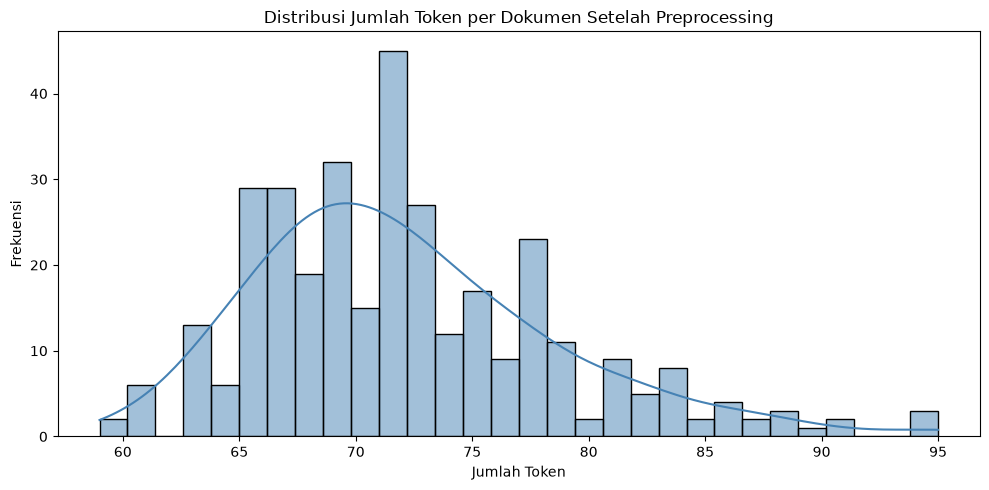

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df['jumlah_token'] = df['step5_stemmed'].apply(len)

print('=== Statistik Jumlah Token per Dokumen ===')
print(df['jumlah_token'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['jumlah_token'], bins=30, kde=True, color='steelblue')
plt.title('Distribusi Jumlah Token per Dokumen Setelah Preprocessing')
plt.xlabel('Jumlah Token')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

## 11. Pembentukan Dictionary & Corpus (Bag of Words)
Mengkonversi token menjadi representasi numerik **Bag of Words** menggunakan Gensim
sebagai input model LDA.

> *"Data teks yang telah bersih kemudian memasuki tahap Pembentukan Dictionary &
Corpus, di mana teks dikonversi menjadi representasi numerik Bag of Words (BoW)
agar dapat diproses oleh mesin."*
> *(Proposal Skripsi, Bab II, hal. 25)*

In [13]:
from gensim import corpora

# Ambil list of list token untuk Gensim
tokenized_docs = df['step5_stemmed'].tolist()

# Buat Dictionary
dictionary = corpora.Dictionary(tokenized_docs)
print(f'Ukuran vocabulary (sebelum filter): {len(dictionary)} kata')

# Filter kata yang terlalu jarang atau terlalu sering muncul
# no_below=2 : hapus kata yang muncul di < 2 dokumen
# no_above=0.85: hapus kata yang muncul di > 85% dokumen
dictionary.filter_extremes(no_below=2, no_above=0.85)
print(f'Ukuran vocabulary (setelah filter) : {len(dictionary)} kata')

# Buat Corpus (Bag of Words)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]
print(f'\nJumlah dokumen dalam corpus: {len(corpus)}')
print('Contoh BoW dokumen ke-0 (5 pertama):', corpus[0][:5])

Ukuran vocabulary (sebelum filter): 990 kata
Ukuran vocabulary (setelah filter) : 325 kata

Jumlah dokumen dalam corpus: 336
Contoh BoW dokumen ke-0 (5 pertama): [(0, 2), (1, 2), (2, 2), (3, 1), (4, 1)]


## 12. Simpan Hasil
Menyimpan:
- **DataFrame bersih** → `data/proses/dataset_preprocessed.csv`
- **Dictionary Gensim** → `data/proses/dictionary.gensim`
- **Corpus Gensim** → `data/proses/corpus.pkl`

In [14]:
import pickle

PROSES_DIR = '../data/proses'
os.makedirs(PROSES_DIR, exist_ok=True)

# Simpan CSV (kolom utama saja)
cols_save = ['Nama', 'Judul', 'Abstrak', 'Tahun', 'teks_gabung', 'teks_bersih', 'step5_stemmed']
df[cols_save].rename(columns={'step5_stemmed': 'tokens'}).to_csv(
    f'{PROSES_DIR}/dataset_preprocessed.csv', index=False
)

# Simpan Dictionary
dictionary.save(f'{PROSES_DIR}/dictionary.gensim')

# Simpan Corpus
with open(f'{PROSES_DIR}/corpus.pkl', 'wb') as f:
    pickle.dump(corpus, f)

print('✅ Semua file berhasil disimpan:')
print(f'   → {PROSES_DIR}/dataset_preprocessed.csv')
print(f'   → {PROSES_DIR}/dictionary.gensim')
print(f'   → {PROSES_DIR}/corpus.pkl')

✅ Semua file berhasil disimpan:
   → ../data/proses/dataset_preprocessed.csv
   → ../data/proses/dictionary.gensim
   → ../data/proses/corpus.pkl


## 13. Ringkasan Hasil Data Preparation
Menampilkan tabel ringkasan hasil setiap tahap preprocessing.

In [15]:
# Tampilkan ringkasan hasil setiap step pada satu dokumen
idx = 0
print('=' * 70)
print(f'RINGKASAN PREPROCESSING — DOKUMEN {idx+1}')
print('=' * 70)
print(f'[1] Teks Gabung   : {df["teks_gabung"].iloc[idx][:100]}...')
print(f'[2] Case Folding  : {df["step1_case_fold"].iloc[idx][:100]}...')
print(f'[3] Cleaning      : {df["step2_clean"].iloc[idx][:100]}...')
print(f'[4] Tokenizing    : {df["step3_tokens"].iloc[idx][:8]}')
print(f'[5] Stop Removal  : {df["step4_nostop"].iloc[idx][:8]}')
print(f'[6] Stemming      : {df["step5_stemmed"].iloc[idx][:8]}')
print(f'[7] Teks Bersih   : {df["teks_bersih"].iloc[idx][:100]}...')
print('=' * 70)
print(f'Total dokumen tersimpan : {len(df)}')
print(f'Ukuran vocabulary       : {len(dictionary)} kata unik')
print(f'Ukuran corpus           : {len(corpus)} dokumen')

RINGKASAN PREPROCESSING — DOKUMEN 1
[1] Teks Gabung   : SISTEM INFORMASI GEOGRAFIS PEMETAAN MANGROVE (STUDI KASUS : BADAN RESTORASI GAMBUT DAN MANGROVE KEC....
[2] Case Folding  : sistem informasi geografis pemetaan mangrove (studi kasus : badan restorasi gambut dan mangrove kec....
[3] Cleaning      : sistem informasi geografis pemetaan mangrove studi kasus badan restorasi gambut dan mangrove kec tul...
[4] Tokenizing    : ['sistem', 'informasi', 'geografis', 'pemetaan', 'mangrove', 'studi', 'kasus', 'badan']
[5] Stop Removal  : ['geografis', 'pemetaan', 'mangrove', 'restorasi', 'gambut', 'mangrove', 'kec', 'tulung']
[6] Stemming      : ['geografis', 'meta', 'mangrove', 'restorasi', 'gambut', 'mangrove', 'kec', 'tulung']
[7] Teks Bersih   : geografis meta mangrove restorasi gambut mangrove kec tulung selapan oki fokus topik geografis meta ...
Total dokumen tersimpan : 336
Ukuran vocabulary       : 325 kata unik
Ukuran corpus           : 336 dokumen
